# Assignment 1 - Step 1

In [1]:
#Import relevant libraries
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# import wind CF data for 6 windfarms and cut to be 24 hours and average out

W1_data = pd.read_csv(r'data_from_Jakob\scen_zone1.csv')
W1_CF = W1_data.iloc[1:25, 1:].mean(axis=1)

W2_data = pd.read_csv(r'data_from_Jakob\scen_zone2.csv')
W2_CF = W2_data.iloc[1:25, 1:].mean(axis=1)

W3_data = pd.read_csv(r'data_from_Jakob\scen_zone3.csv')
W3_CF = W3_data.iloc[1:25, 1:].mean(axis=1)

W4_data = pd.read_csv(r'data_from_Jakob\scen_zone4.csv')
W4_CF = W4_data.iloc[1:25, 1:].mean(axis=1)

W5_data = pd.read_csv(r'data_from_Jakob\scen_zone5.csv')
W5_CF = W5_data.iloc[1:25, 1:].mean(axis=1)

W6_data = pd.read_csv(r'data_from_Jakob\scen_zone6.csv')
W6_CF = W6_data.iloc[1:25, 1:].mean(axis=1)


In [3]:
from data import load_distribution, load_profile, generators, generator_bid_prices
from data import Prices_for_loads, transmission_lines

#create variable list with the names of the variables as strings
VARIABLES = list(generators.keys())

LOAD_VARIABLES = list(load_distribution.keys())

VOLTAGE_ANGLES = [f"theta_{i}" for i in range(1, 25)]

#create a list of the cost coefficients for each variable
Generation_price = [v[1] for v in generator_bid_prices.values()]

#writes a list that converts the cost coefficient to this form objective_coeff = {'G1': 13.32, 'G2': 13.32, ...}
objective_coeff = {VARIABLES[i]: Generation_price[i] for i in range(len(VARIABLES))}



#write the load percentages for each node
Load_percentage = [v['percent'] for v in load_distribution.values()]
#multiply the load percentage with the total load to get the actual load in MW
hour1_load = load_profile[1] #MW
#hour1_load = 2650.5 #Max demand check only used for testing
#Load upper bound list for each load variable
Load = [hour1_load * (i / 100) for i in Load_percentage] #MW


#random price list with 17 values and sort it in descending order
#change prices for clarity in the plot
Randonm_prices_h1 = Prices_for_loads[1]
Demand_price= np.array(sorted(Randonm_prices_h1, reverse=True)) -60 #$/MWh 

#writes a list that converts the load coefficient to this form objective_coeff = {'Load1': 13.32, 'Load2': 13.32, ...}
Load_coefficients = {LOAD_VARIABLES[i]: Demand_price[i] for i in range(len(LOAD_VARIABLES))}

#create a upper bound for the production variables
Generator_UB = [v['Pmax_MW'] for k, v in generators.items() if k.startswith('G')]

#Generator_UB = [152,152,350,591,60,155,155,400,400,300,310,350] #MW
Wind_UB = np.array([W1_CF[1], W2_CF[1], W3_CF[1], W4_CF[1],W5_CF[1],W6_CF[1]])*200
Constraints_rhs = Generator_UB + Wind_UB.tolist()
#create constraints sense list with 18 values of GRB.LESS_EQUAL
constraints_sense = [GRB.LESS_EQUAL] * 18




In [4]:
#Create model
model = gp.Model("Copperplate_singlehour")

Set parameter Username
Set parameter LicenseID to value 2776545
Academic license - for non-commercial use only - expires 2027-02-08


In [5]:
#Add variables
variables = {v: model.addVar(lb=0, name=f'variable {v}') for v in VARIABLES}

#Add load variables
load_variables = {l: model.addVar(lb=0, name=f'variable {l}') for l in LOAD_VARIABLES}

#Add voltage angle variables
voltage_angle_variables = {n: model.addVar(lb=-GRB.INFINITY, name=f'variable {n}') for n in range(1,25)}

slack_constraint = model.addConstr(voltage_angle_variables[13] == 0, name='Slack_constraint')



In [6]:
# Set objective function and optimization direction of the Gurobi model
objective = gp.quicksum(Load_coefficients[v] * load_variables[v] for v in LOAD_VARIABLES) - gp.quicksum(objective_coeff[v] * variables[v] for v in VARIABLES)
model.setObjective(objective, GRB.MAXIMIZE)


In [7]:
# Add constraints to the Gurobi model

#Add balance constraint to the Gurobi model that ensures that the total load is equal to the total generation
Balance_constraints = {}
for n in range(1, 25):

    Balance_constraints[n] = model.addLConstr(

        # Load at node n
        gp.quicksum(
            load_variables[v]
            for v in load_variables
            if load_distribution[v]['node'] == n
        )

        # minus Generation at node n
        - gp.quicksum(
            variables[v]
            for v in variables
            if generators[v]['node'] == n
        )

        +gp.quicksum(
            (voltage_angle_variables[n] -
             voltage_angle_variables[
                 transmission_lines[v]['to']
                 if transmission_lines[v]['from'] == n
                 else transmission_lines[v]['from']
             ]) / transmission_lines[v]['reactance']

            for v in transmission_lines
            if transmission_lines[v]['from'] == n
            or transmission_lines[v]['to'] == n
        ),

        GRB.EQUAL,
        0,
        name=f"Balance_constraint_{n}"
    )

#Balance_constraint = [
 #   model.addLConstr(
  #      gp.quicksum(load_variables[v] for v in load_variables)-gp.quicksum(variables[v] for v in variables), GRB.EQUAL, 0,
   #     name=f"Balance_constraint" 
   # )
    
#]

#Add boundary constraints to the Gurobi model that ensures that the generation of each generator is less than or equal to its upper bound
Boundary_constraints = {}

for v, rhs in zip(VARIABLES, Constraints_rhs):
    Boundary_constraints[v] = model.addLConstr(
        variables[v],
        GRB.LESS_EQUAL,
        rhs
    )

Boundary_constraints2 = {}
for v, rhs in zip(LOAD_VARIABLES, Load):
    Boundary_constraints2[v] = model.addLConstr(
        load_variables[v],
        GRB.LESS_EQUAL,
        rhs
    )

Boundary_constraints_lines = {}  # store line capacity constraints

for v in transmission_lines:  # v = line key
    i = transmission_lines[v]['from']
    j = transmission_lines[v]['to']
    X = transmission_lines[v]['reactance']
    Pmax = transmission_lines[v]['capacity_MVA']

    # Upper bound
    Boundary_constraints_lines[f"{v}_upper"] = model.addLConstr(
        (voltage_angle_variables[i] - voltage_angle_variables[j]) / X,
        GRB.LESS_EQUAL,
        Pmax,
        name=f"Line_{v}_upper"
    )

    # Lower bound
    Boundary_constraints_lines[f"{v}_lower"] = model.addLConstr(
        (voltage_angle_variables[i] - voltage_angle_variables[j]) / X,
        GRB.GREATER_EQUAL,
        -Pmax,
        name=f"Line_{v}_lower"
    )

In [8]:
model.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 128 rows, 59 columns and 299 nonzeros (Max)
Model fingerprint: 0xf876edc9
Model has 28 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [1e+00, 4e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+01, 1e+03]

Presolve removed 95 rows and 11 columns
Presolve time: 0.04s
Presolved: 33 rows, 65 columns, 181 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
      32    1.3721110e+04   0.000000e+00   0.000000e+00      0s

Solved in 32 iterations and 0.07 seconds (0.00 work units)
Optimal objective  1.372110966e+04


In [9]:
# check that balance is maintained at each node
for n in range(1, 25):
    generation = sum(variables[v].X for v in variables if generators[v]['node'] == n)
    load = sum(load_variables[v].X for v in load_variables if load_distribution[v]['node'] == n)
    
    # sum flows on all lines connected to this node
    transmission = sum(
        (voltage_angle_variables[n].X - 
         voltage_angle_variables[transmission_lines[v]['to']].X) / transmission_lines[v]['reactance']
        if transmission_lines[v]['from'] == n
        else
        (voltage_angle_variables[n].X - 
         voltage_angle_variables[transmission_lines[v]['from']].X) / transmission_lines[v]['reactance']
        for v in transmission_lines
        if transmission_lines[v]['from'] == n or transmission_lines[v]['to'] == n
    )
    
    net_balance = generation - load - transmission
    print(f"sum of balance at node {n}: {net_balance:.6f} MW (should be close to 0)")

sum of balance at node 1: 0.000000 MW (should be close to 0)
sum of balance at node 2: 0.000000 MW (should be close to 0)
sum of balance at node 3: 0.000000 MW (should be close to 0)
sum of balance at node 4: 0.000000 MW (should be close to 0)
sum of balance at node 5: 0.000000 MW (should be close to 0)
sum of balance at node 6: -0.000000 MW (should be close to 0)
sum of balance at node 7: 0.000000 MW (should be close to 0)
sum of balance at node 8: -0.000000 MW (should be close to 0)
sum of balance at node 9: 0.000000 MW (should be close to 0)
sum of balance at node 10: -0.000000 MW (should be close to 0)
sum of balance at node 11: 0.000000 MW (should be close to 0)
sum of balance at node 12: 0.000000 MW (should be close to 0)
sum of balance at node 13: 0.000000 MW (should be close to 0)
sum of balance at node 14: 0.000000 MW (should be close to 0)
sum of balance at node 15: 0.000000 MW (should be close to 0)
sum of balance at node 16: -0.000000 MW (should be close to 0)
sum of balanc

In [10]:
# write all the market prices
if model.status == GRB.OPTIMAL:
    for n in range(1, 25):
        print(f"Market price at node {n}: {Balance_constraints[n].Pi:.2f} $/MWh")

Market price at node 1: 13.32 $/MWh
Market price at node 2: 13.32 $/MWh
Market price at node 3: 11.12 $/MWh
Market price at node 4: 28.18 $/MWh
Market price at node 5: -0.00 $/MWh
Market price at node 6: 23.66 $/MWh
Market price at node 7: -0.00 $/MWh
Market price at node 8: 18.37 $/MWh
Market price at node 9: 12.05 $/MWh
Market price at node 10: 9.82 $/MWh
Market price at node 11: 11.95 $/MWh
Market price at node 12: 10.64 $/MWh
Market price at node 13: 15.26 $/MWh
Market price at node 14: 10.09 $/MWh
Market price at node 15: 8.77 $/MWh
Market price at node 16: 3.96 $/MWh
Market price at node 17: 0.38 $/MWh
Market price at node 18: 1.50 $/MWh
Market price at node 19: 2.54 $/MWh
Market price at node 20: 1.30 $/MWh
Market price at node 21: -0.25 $/MWh
Market price at node 22: -0.00 $/MWh
Market price at node 23: 0.62 $/MWh
Market price at node 24: 9.68 $/MWh


In [11]:
# Dictionary to store flows
line_flows = {}

for v in transmission_lines:
    from_node = transmission_lines[v]['from']
    to_node = transmission_lines[v]['to']
    X = transmission_lines[v]['reactance']

    # DC flow
    P_ij = (voltage_angle_variables[from_node].X - voltage_angle_variables[to_node].X) / X
    line_flows[v] = P_ij

In [12]:
# Dictionary to store flows
line_flows = {}

for v in transmission_lines:
    from_node = transmission_lines[v]['from']
    to_node = transmission_lines[v]['to']
    X = transmission_lines[v]['reactance']

    # DC flow
    P_ij = (voltage_angle_variables[from_node].X - voltage_angle_variables[to_node].X) / X
    line_flows[v] = P_ij

In [13]:
for v in transmission_lines:
    from_node = transmission_lines[v]['from']
    to_node = transmission_lines[v]['to']
    price_diff = Balance_constraints[from_node].Pi - Balance_constraints[to_node].Pi

    print(f"Line {v}: Flow = {line_flows[v]:.2f} MW, Capacity = {transmission_lines[v]['capacity_MVA']} MW, "
          f"Price difference = {price_diff:.2f} $/MWh")

Line L1: Flow = -17.00 MW, Capacity = 17 MW, Price difference = 0.00 $/MWh
Line L2: Flow = -6.42 MW, Capacity = 17 MW, Price difference = 2.20 $/MWh
Line L3: Flow = -35.00 MW, Capacity = 35 MW, Price difference = 13.32 $/MWh
Line L4: Flow = 17.00 MW, Capacity = 17 MW, Price difference = -14.86 $/MWh
Line L5: Flow = 7.10 MW, Capacity = 17 MW, Price difference = -10.34 $/MWh
Line L6: Flow = 12.72 MW, Capacity = 17 MW, Price difference = -0.93 $/MWh
Line L7: Flow = -12.47 MW, Capacity = 40 MW, Price difference = 1.44 $/MWh
Line L8: Flow = -17.00 MW, Capacity = 17 MW, Price difference = 16.13 $/MWh
Line L9: Flow = 35.00 MW, Capacity = 35 MW, Price difference = -9.82 $/MWh
Line L10: Flow = -17.00 MW, Capacity = 17 MW, Price difference = 13.84 $/MWh
Line L11: Flow = 35.00 MW, Capacity = 35 MW, Price difference = -18.37 $/MWh
Line L12: Flow = -16.69 MW, Capacity = 17 MW, Price difference = 6.32 $/MWh
Line L13: Flow = -17.00 MW, Capacity = 17 MW, Price difference = 8.55 $/MWh
Line L14: Flow = 

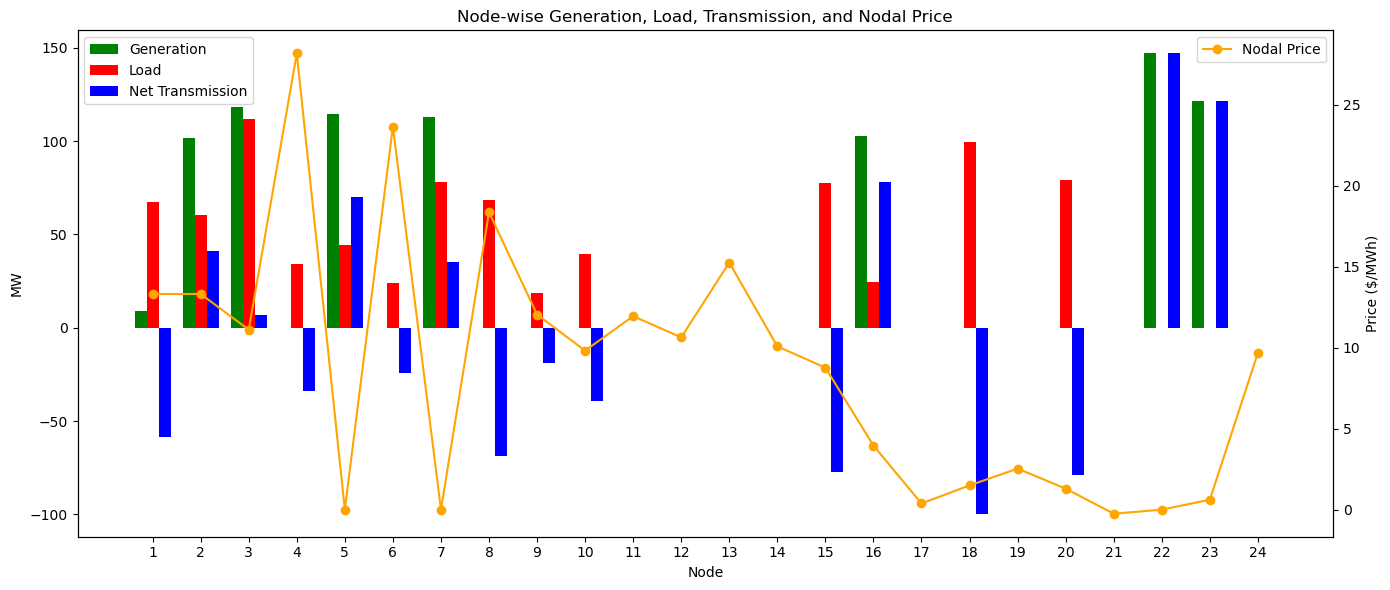

In [14]:
import matplotlib.pyplot as plt
import numpy as np

nodes = range(1, 25)

# Gather data for plotting
generation = [sum(variables[v].X for v in variables if generators[v]['node'] == n) for n in nodes]
load = [sum(load_variables[v].X for v in load_variables if load_distribution[v]['node'] == n) for n in nodes]

# Net transmission leaving each node
transmission = []
for n in nodes:
    net_flow = sum(
        (voltage_angle_variables[n].X - 
         voltage_angle_variables[transmission_lines[v]['to']].X) / transmission_lines[v]['reactance']
        if transmission_lines[v]['from'] == n
        else
        (voltage_angle_variables[n].X - 
         voltage_angle_variables[transmission_lines[v]['from']].X) / transmission_lines[v]['reactance']
        for v in transmission_lines
        if transmission_lines[v]['from'] == n or transmission_lines[v]['to'] == n
    )
    transmission.append(net_flow)

# Nodal prices
prices = [Balance_constraints[n].Pi for n in nodes]

# Start plotting
fig, ax1 = plt.subplots(figsize=(14,6))

# Bar width
width = 0.25
x = np.array(nodes)

# Plot generation, load, transmission as bars
ax1.bar(x - width, generation, width, label='Generation', color='green')
ax1.bar(x, load, width, label='Load', color='red')
ax1.bar(x + width, transmission, width, label='Net Transmission', color='blue')

ax1.set_xlabel('Node')
ax1.set_ylabel('MW')
ax1.set_xticks(x)
ax1.set_xticklabels(nodes)
ax1.legend(loc='upper left')

# Secondary axis for price
ax2 = ax1.twinx()
ax2.plot(x, prices, color='orange', marker='o', linestyle='-', label='Nodal Price')
ax2.set_ylabel('Price ($/MWh)')
ax2.legend(loc='upper right')

plt.title('Node-wise Generation, Load, Transmission, and Nodal Price')
plt.tight_layout()
plt.show()

In [15]:
# check status and print results
# TBD 
if model.status == GRB.OPTIMAL:
    print(f"Optimal objective: {model.ObjVal}")
    print(f"Optimal Dual value of load constraint(Market clearing price): {Balance_constraints[5].Pi:.2f} $/MWh")
    for i in VARIABLES:
        print(f"Optimal dispatch of generator {i}: {variables[i].X:.2f} MW")
    for i in LOAD_VARIABLES:
        print(f"Optimal dispatch of load {i}: {load_variables[i].X:.2f} MW")
    
    
    
    for i in VARIABLES:
        print(f"Dual value of capacity constraint for generator {i}: {Boundary_constraints[i].Pi}")
    for i in LOAD_VARIABLES:
        print(f"Dual value of demand constraint for load {i}: {Boundary_constraints2[i].Pi}")
else:
    print(f"optimization of {model.ModelName} was not successful")

Optimal objective: 13721.109660241902
Optimal Dual value of load constraint(Market clearing price): -0.00 $/MWh
Optimal dispatch of generator G1: 9.06 MW
Optimal dispatch of generator G2: 101.48 MW
Optimal dispatch of generator G3: 0.00 MW
Optimal dispatch of generator G4: 0.00 MW
Optimal dispatch of generator G5: 0.00 MW
Optimal dispatch of generator G6: 0.00 MW
Optimal dispatch of generator G7: 0.00 MW
Optimal dispatch of generator G8: 0.00 MW
Optimal dispatch of generator G9: 0.00 MW
Optimal dispatch of generator G10: 147.07 MW
Optimal dispatch of generator G11: 0.00 MW
Optimal dispatch of generator G12: 0.00 MW
Optimal dispatch of generator W1: 118.54 MW
Optimal dispatch of generator W2: 114.40 MW
Optimal dispatch of generator W3: 113.14 MW
Optimal dispatch of generator W4: 102.78 MW
Optimal dispatch of generator W5: 0.00 MW
Optimal dispatch of generator W6: 121.69 MW
Optimal dispatch of load Load1: 67.48 MW
Optimal dispatch of load Load2: 60.38 MW
Optimal dispatch of load Load3: 1

In [16]:
#printing the market clearing price
print(f"Under a uniform pricing scheme\n the market clearing price: {Balance_constraints[1].Pi} $/MWh")

#the total operating cost of the system
total_cost = sum(objective_coeff[v] * variables[v].X for v in VARIABLES)
print(f"Total operating cost of the system: {total_cost:.2f} $")

#The social welfare of the system
social_welfare = model.ObjVal
print(f"Social welfare of the system: {social_welfare:.2f} $")

Production_surplus = sum((Balance_constraints[1].Pi - objective_coeff[i]) * variables[i].X for i in VARIABLES)
print(f"Total production surplus: {Production_surplus:.2f} $")
Consumer_surplus = sum((Load_coefficients[i] - Balance_constraints[1].Pi) * load_variables[i].X for i in LOAD_VARIABLES)
print(f"Total consumer surplus: {Consumer_surplus:.2f} $")

#the profit of each producer
for i in VARIABLES:
    profit = (Balance_constraints[1].Pi - objective_coeff[i]) * variables[i].X
    print(f"Profit of generator {i}: {profit:.2f} $")

#the utility of each consumer
for i in LOAD_VARIABLES:
    utility = (Load_coefficients[i] - Balance_constraints[1].Pi) * load_variables[i].X
    print(f"Utility of consumer {i}: {utility:.2f} $")




Under a uniform pricing scheme
 the market clearing price: 13.32 $/MWh
Total operating cost of the system: 1472.37 $
Social welfare of the system: 13721.11 $
Total production surplus: 9558.78 $
Total consumer surplus: 4162.33 $
Profit of generator G1: 0.00 $
Profit of generator G2: 0.00 $
Profit of generator G3: -0.00 $
Profit of generator G4: -0.00 $
Profit of generator G5: -0.00 $
Profit of generator G6: 0.00 $
Profit of generator G7: 0.00 $
Profit of generator G8: 0.00 $
Profit of generator G9: 0.00 $
Profit of generator G10: 1959.02 $
Profit of generator G11: 0.00 $
Profit of generator G12: 0.00 $
Profit of generator W1: 1578.97 $
Profit of generator W2: 1523.75 $
Profit of generator W3: 1506.98 $
Profit of generator W4: 1369.09 $
Profit of generator W5: 0.00 $
Profit of generator W6: 1620.96 $
Utility of consumer Load1: 1705.94 $
Utility of consumer Load2: 1121.83 $
Utility of consumer Load3: 1791.16 $
Utility of consumer Load4: 505.24 $
Utility of consumer Load5: 639.74 $
Utility

[300, 118.54163745949499, 139.63512850803707, 135.50204551881356, 102.78490618913705, 131.59804421716413, 121.69374011796054, 400, 400, 155, 155, 310, 350, 152, 152, 350, 591, 60]


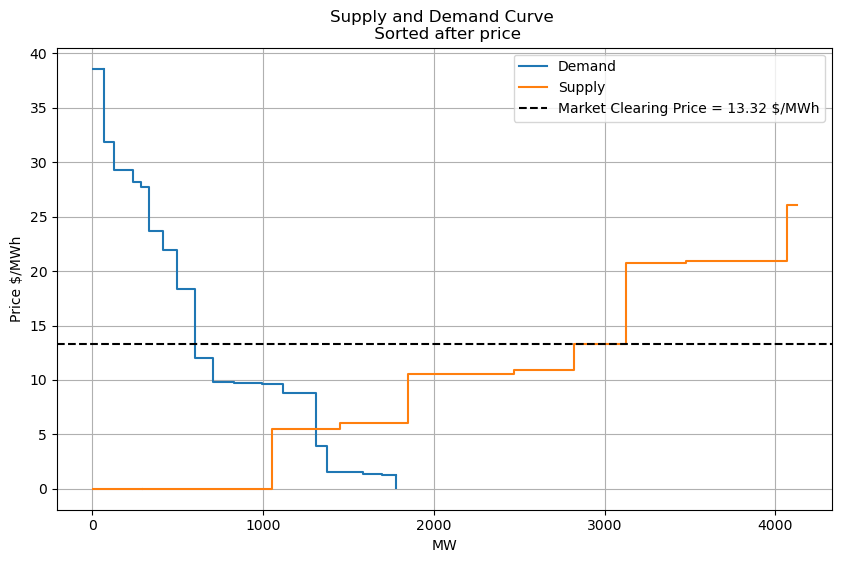

In [17]:
#sorting data for plotting the supply and demand curve
supply_data = [
    (Generation_price[i], VARIABLES[i], variables[VARIABLES[i]].X, Constraints_rhs[i])
    for i in range(len(VARIABLES))
]
supply_data_sorted = sorted(supply_data, key=lambda x: x[0])
sorted_prices = [x[0] for x in supply_data_sorted]
sorted_dispatch = [x[3] for x in supply_data_sorted] ### changed for plotting
cumulative_supply = np.cumsum(sorted_dispatch)

print(sorted_dispatch)

#plot the supply and demand curve
plt.figure(figsize=(10, 6))
plt.step(np.cumsum(Load), Demand_price, label='Demand')
plt.step(cumulative_supply, sorted_prices, label='Supply')

#plot purely for aestetic reason
plt.hlines(y=0, xmin=0, xmax=cumulative_supply[0], color='tab:orange')
plt.hlines(y=Demand_price[0], xmin=0, xmax=Load[0], color='tab:blue')
plt.vlines(x=np.cumsum(Load)[-1], ymin=0, ymax=np.min(Demand_price), color='tab:blue')

#plot marketclearing price
plt.axhline(y=Balance_constraints[1].Pi, color='black', linestyle='--', label=f'Market Clearing Price = {Balance_constraints[1].Pi:.2f} $/MWh')

#final plotting details
plt.xlabel('MW')
plt.ylabel('Price $/MWh')
plt.title('Supply and Demand Curve \n Sorted after price')
plt.legend()
plt.grid()
plt.show()


**KKT cconditions**

In [18]:
# ============================================================
# KKT Verification of Market-Clearing Price
# ============================================================

lambda_ = Balance_constraint[0].Pi  # Market-clearing price (dual of balance constraint)
print("=" * 60)
print(f"Market-Clearing Price (λ): {lambda_:.2f} $/MWh")
print("=" * 60)

print("\n--- KKT CONDITIONS VERIFICATION ---\n")

# -------------------------------------------------------
# 1. STATIONARITY CONDITIONS
# -------------------------------------------------------
# For generators: ∂L/∂g_i = c_i - λ + μ_i = 0  =>  μ_i = λ - c_i
# For loads:      ∂L/∂d_j = -u_j + λ + ν_j = 0  =>  ν_j = u_j - λ

print("STATIONARITY CONDITIONS:")
print("\nGenerators: c_i - λ + μ_i = 0  →  μ_i = λ - c_i")
for i in VARIABLES:
    c_i = objective_coeff[i]
    mu_i = Boundary_constraints[i].Pi          # dual of capacity constraint
    stationarity_check = c_i - lambda_ + mu_i
    print(f"  Generator {i}: c_i={c_i:.2f}, μ_i={mu_i:.4f}, "
          f"c_i - λ + μ_i = {stationarity_check:.6f}  ✓" if abs(stationarity_check) < 1e-4
          else f"  Generator {i}: c_i={c_i:.2f}, μ_i={mu_i:.4f}, "
               f"c_i - λ + μ_i = {stationarity_check:.6f}  ✗")

print("\nLoads: -u_j + λ + ν_j = 0  →  ν_j = u_j - λ")
for j in LOAD_VARIABLES:
    u_j = Load_coefficients[j]
    nu_j = Boundary_constraints2[j].Pi         # dual of demand constraint (≥ 0)
    stationarity_check = -u_j + lambda_ + nu_j
    print(f"  Load {j}: u_j={u_j:.2f}, ν_j={nu_j:.4f}, "
          f"-u_j + λ + ν_j = {stationarity_check:.6f}  ✓" if abs(stationarity_check) < 1e-4
          else f"  Load {j}: u_j={u_j:.2f}, ν_j={nu_j:.4f}, "
               f"-u_j + λ + ν_j = {stationarity_check:.6f}  ✗")

# -------------------------------------------------------
# 2. COMPLEMENTARY SLACKNESS + PRICE INTERPRETATION
# -------------------------------------------------------
print("\n" + "=" * 60)
print("COMPLEMENTARY SLACKNESS & PRICE INTERPRETATION:")
print("=" * 60)

print("\nGenerators  [μ_i*(g_i_max - g_i) = 0]:")
for i in VARIABLES:
    g_i    = variables[i].X
    g_max  = Constraints_rhs[list(VARIABLES).index(i)]
    mu_i   = Boundary_constraints[i].Pi
    cs     = mu_i * (g_max - g_i)
    c_i    = objective_coeff[i]
    slack  = g_max - g_i

    if slack > 1e-4:          # Not at capacity  →  μ_i = 0  →  λ = c_i
        status = "ACCEPTED (inframarginal)" if c_i < lambda_ - 1e-4 else "MARGINAL"
        interpretation = f"λ = c_i = {c_i:.2f}  (sets the price)" if abs(c_i - lambda_) < 1e-4 \
                         else f"c_i={c_i:.2f} < λ={lambda_:.2f}  (earns positive surplus)"
    else:                      # At capacity      →  μ_i ≥ 0  →  λ ≥ c_i
        status = "ACCEPTED (at capacity)"
        interpretation = f"μ_i={mu_i:.2f} ≥ 0, c_i={c_i:.2f} ≤ λ={lambda_:.2f}"

    print(f"  Generator {i} [{status}]: g={g_i:.2f}/{g_max:.2f} MW, "
          f"μ_i={mu_i:.4f}, CS={cs:.6f}  |  {interpretation}")

print("\nLoads  [ν_j*(d_j_max - d_j) = 0]:")
for j in LOAD_VARIABLES:
    d_j    = load_variables[j].X
    d_max  = Load[list(LOAD_VARIABLES).index(j)]
    nu_j   = Boundary_constraints2[j].Pi
    cs     = nu_j * (d_max - d_j)
    u_j    = Load_coefficients[j]
    slack  = d_max - d_j

    if slack > 1e-4:          # Not at max demand  →  ν_j = 0  →  λ = u_j
        status = "ACCEPTED (inframarginal)" if u_j > lambda_ + 1e-4 else "MARGINAL"
        interpretation = f"λ = u_j = {u_j:.2f}  (sets the price)" if abs(u_j - lambda_) < 1e-4 \
                         else f"u_j={u_j:.2f} > λ={lambda_:.2f}  (earns positive surplus)"
    else:                      # At max demand      →  ν_j = 0 automatically (fully served)
        status = "ACCEPTED (fully served)"
        interpretation = f"ν_j={nu_j:.4f}, u_j={u_j:.2f} ≥ λ={lambda_:.2f}"

    print(f"  Load {j} [{status}]: d={d_j:.2f}/{d_max:.2f} MW, "
          f"ν_j={nu_j:.4f}, CS={cs:.6f}  |  {interpretation}")


NameError: name 'Balance_constraint' is not defined